In [1]:
from google.colab import files
uploaded = files.upload()

Saving X data.csv to X data.csv


In [5]:
import pandas as pd

df = pd.read_csv("X data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [6]:
print(df.columns)

Index(['clean_text', 'category'], dtype='object')


In [7]:
df['Sentiment'] = df['category'].map({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
})

df.head()

,clean_text,category,Sentiment
0,when modi promised “minimum government maximum...,-1.0,Negative
1,talk all the nonsense and continue all the dra...,0.0,Neutral
2,what did just say vote for modi welcome bjp t...,1.0,Positive
3,asking his supporters prefix chowkidar their n...,1.0,Positive
4,answer who among these the most powerful world...,1.0,Positive


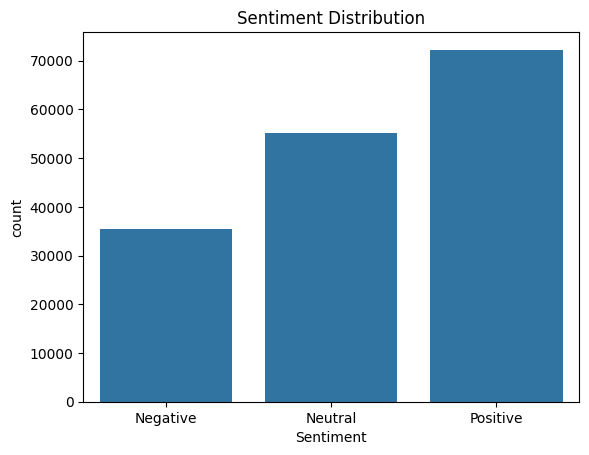

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

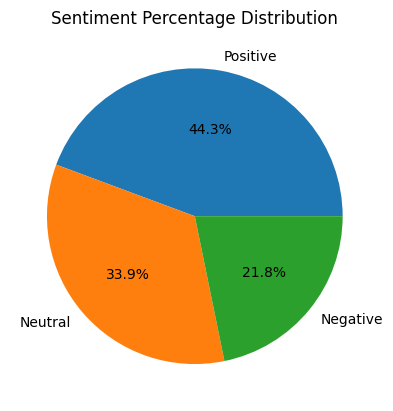

In [9]:
sentiment_counts = df['Sentiment'].value_counts()

sentiment_counts.plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Percentage Distribution")
plt.ylabel('')
plt.show()

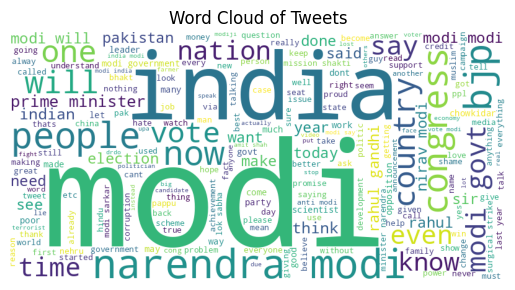

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# remove missing values + convert to string
text = " ".join(df['clean_text'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Tweets")
plt.show()

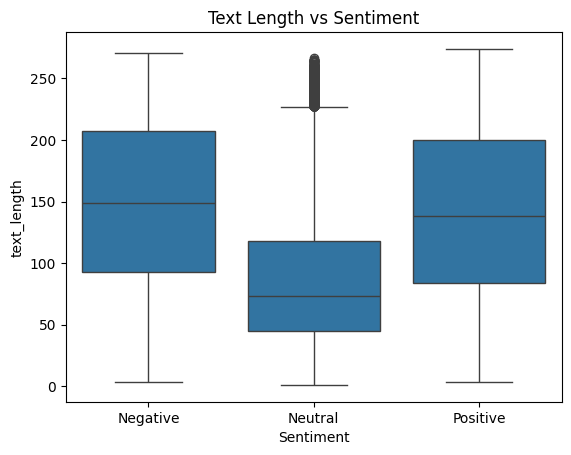

In [12]:
# create text length column
df['text_length'] = df['clean_text'].astype(str).apply(len)

# boxplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Sentiment', y='text_length', data=df)
plt.title("Text Length vs Sentiment")
plt.show()